# Super League player and position importance

This notebook estimates how the selection of individual players changes a team's scoring and defence. The workflow is deliberately simple:

1. join Patreon player rows to the actual fixture results,
2. build a fixture-level player-selection matrix,
3. fit a regularised player model,
4. inspect position-group effects,
5. validate the result in a chronological backtest before moving anything into production.

**Interpretation:** `attack_rating` is the estimated extra team points associated with a player when selected; `defence_rating` is the estimated points prevented. These are conditional associations, not causal claims. Ratings are shrunk toward zero and adjusted for team, opponent, and home/away context. Fixture dates from the results feed are used for chronological ordering.

### Why Ridge is used here

The player matrix is sparse and highly collinear: the same players often appear together, some players have very few appearances, and selection is not random. A plain linear model can easily overfit to noisy combinations of players.

We therefore estimate coefficients with Ridge regression:

$$
\hat{\beta} = \arg\min_\beta \|y - X\beta\|_2^2 + \alpha \|\beta\|_2^2
$$

where:
- $y$ is the target such as points scored or points conceded,
- $X$ is the fixture-by-player selection matrix,
- $\beta$ is the player contribution vector,
- $\alpha$ is the regularisation strength.

### Worked example

Suppose we have three players, A, B and C, and three fixtures:

| Fixture | A | B | C | Team points |
|---|---:|---:|---:|---:|
| 1 | 1 | 0 | 1 | 26 |
| 2 | 1 | 1 | 0 | 22 |
| 3 | 0 | 1 | 1 | 24 |

If A and B tend to play together, a plain OLS fit can assign unstable, inflated coefficients to both because they are correlated. Ridge adds a penalty on the size of the coefficients, so the model prefers a more stable estimate instead of chasing noise.

In practical terms, this means a player with only a small sample is shrunk back toward zero unless the data strongly supports a large effect. That is exactly the right behaviour for player ratings in a Rugby League context.

### Production decision rule

This notebook is not trying to prove a single snapshot works. The real gate is a walk-forward backtest:

- train on all fixtures before the evaluation date,
- predict on later fixtures,
- compare baseline vs player-adjusted MAE/RMSE.

If the player-adjusted model clearly beats the baseline in a genuine walk-forward experiment, it is worth moving into production. If it does not, the team-news pipeline stays untouched.


In [1]:
from pathlib import Path
import warnings
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Resolve data directories from either project root or notebook-relative execution.
player_dir_candidates = [
    Path('data/raw/patreon/players'),
    Path('../../../data/raw/patreon/players'),
    Path('/workspaces/rugby_league_pricing/data/raw/patreon/players'),
]
results_dir_candidates = [
    Path('data/raw/patreon/results'),
    Path('../../../data/raw/patreon/results'),
    Path('/workspaces/rugby_league_pricing/data/raw/patreon/results'),
]
PLAYER_DIR = next((p for p in player_dir_candidates if p.exists()), player_dir_candidates[0])
RESULTS_DIR = next((p for p in results_dir_candidates if p.exists()), results_dir_candidates[0])

player_files = sorted(PLAYER_DIR.glob('*.csv'))
results_files = sorted(RESULTS_DIR.glob('*.csv'))
assert player_files, (
    'No player CSV files found. Searched: ' + ', '.join(str(p) for p in player_dir_candidates)
    + f' | current cwd: {Path.cwd()}'
)
assert results_files, (
    'No results CSV files found. Searched: ' + ', '.join(str(p) for p in results_dir_candidates)
    + f' | current cwd: {Path.cwd()}'
)

PLAYER_FILES = [
    path for path in player_files
    if path.name in {'sl_player_data_19_25.csv', '2026_sl_player_data.csv'}
]
RESULTS_FILES = [
    path for path in results_files
    if path.name in {'sl_results_data_19_25.csv', '2026_sl_fixture_data.csv'}
]
assert PLAYER_FILES, f'No target player CSV files found in {PLAYER_DIR}'
assert RESULTS_FILES, f'No target results CSV files found in {RESULTS_DIR}'

print('Using player files:')
for path in PLAYER_FILES:
    print(f' - {path}')
print('Using results files:')
for path in RESULTS_FILES:
    print(f' - {path}')

ORDER_COL = 'fixture_date'
MIN_APPEARANCES = 12
RIDGE_ALPHA = 35.0
TEST_FRACTION = 0.20
TOP_N = 25
for path in PLAYER_FILES + RESULTS_FILES:
    assert path.exists(), f'File not found: {path}'

Using player files:
 - ../../../data/raw/patreon/players/2026_sl_player_data.csv
 - ../../../data/raw/patreon/players/sl_player_data_19_25.csv
Using results files:
 - ../../../data/raw/patreon/results/2026_sl_fixture_data.csv
 - ../../../data/raw/patreon/results/sl_results_data_19_25.csv


### How the notebook is structured

This notebook intentionally separates the analysis into four layers:

1. raw player and results ingestion,
2. fixture-level target construction,
3. Ridge player model estimation,
4. walk-forward validation and decision gate.

The first two sections are only there to create a clean, date-ordered training matrix. The model section is where the inferential work happens. The final validation section is where production decisions are made.

### Walk-forward validation: what it means in practice

A hold-out split such as “last 20% of fixtures” is useful for a quick check, but it is not enough for production. A genuine walk-forward test uses expanding windows:

- train on all fixtures before date $t$,
- score the next fixture window,
- move forward one round at a time,
- repeat until the end of the data.

This ensures we only use information that would have been available at the time, and it avoids optimistic bias from future leakage.

### Example: Ridge in one line

If $X$ is the player selection matrix and $y$ is the team scoring target, the model says:

$$
\hat{\beta} = (X^\top X + \alpha I)^{-1} X^\top y
$$

The identity term $I$ is what makes the solution stable when players are correlated. A player with a noisy or thin history is shrunk toward zero rather than being assigned an exaggerated coefficient.

This is exactly why Ridge is the right choice before any production handoff.


## 1. Load and audit the source

This section is intentionally lightweight. Its purpose is to validate that the data match the expected schema, that dates are present, and that the player and results feeds line up at the fixture level. It does not produce the final model; it just creates the clean input table.

The most important checks are:
- player rows have the required event columns,
- results rows contain the full-time scoreline and fixture date,
- duplicate fixture-player rows are consolidated,
- all selected player fixtures exist in the results feed.

These checks matter because the modelling step is only as good as the chronological alignment between the player feed and the actual match events.


In [2]:
raw = pd.concat([pd.read_csv(path) for path in PLAYER_FILES], ignore_index=True)
results_raw = pd.concat([pd.read_csv(path) for path in RESULTS_FILES], ignore_index=True)

required = {'fixture_id','player_id','player_name','position_id','team_id','opposition_id',
            'tries','goals_made','drop_goals','tackles_made','tackles_missed'}
missing = required - set(raw.columns)
assert not missing, f'Missing required columns: {missing}'

results_required = {
    'fixture_id', 'fixture_date', 'home_team', 'away_team',
    'home_ft_score', 'away_ft_score', 'neutral_venue'
}
results_missing = results_required - set(results_raw.columns)
assert not results_missing, f'Missing required results columns: {results_missing}'

results_raw['fixture_date'] = pd.to_datetime(results_raw['fixture_date'], errors='raise')
assert not results_raw.duplicated(['fixture_id']).any(), 'Duplicate fixture IDs found in results data'

player_fixture_ids = pd.Index(raw['fixture_id'].unique())
results_fixture_ids = pd.Index(results_raw['fixture_id'].unique())

audit = pd.Series({
    'rows': len(raw), 'fixtures': raw.fixture_id.nunique(),
    'players': raw.player_id.nunique(), 'team labels': raw.team_id.nunique(),
    'source files': len(PLAYER_FILES), 'results files': len(RESULTS_FILES),
    'results fixtures': results_raw.fixture_id.nunique(),
    'duplicate fixture-player rows': raw.duplicated(['fixture_id','player_id']).sum(),
    'fixtures without exactly two teams': (raw.groupby('fixture_id').team_id.nunique() != 2).sum(),
    'player fixtures missing results': len(player_fixture_ids.difference(results_fixture_ids)),
})
display(audit.to_frame('value'))
display(raw.isna().sum().loc[lambda s: s.gt(0)].to_frame('missing'))
display(results_raw[['fixture_date','home_ft_score','away_ft_score']].isna().sum().to_frame('missing'))
display(raw.position_id.value_counts(dropna=False).sort_index().to_frame('rows'))

,value
rows,43836
fixtures,1246
players,993
team labels,18
source files,2
results files,2
results fixtures,1246
duplicate fixture-player rows,179
fixtures without exactly two teams,0
player fixtures missing results,0


,missing
fixture_url,6086
drop_goals,1292
yellow_cards,1292
red_cards,1292


,missing
fixture_date,0
home_ft_score,0
away_ft_score,0


,rows
position_id,
1,2497
2,2501
3,2499
4,2505
5,2510
6,2505
7,2501
8,2501
9,2504


In [3]:
# Consolidate duplicate player-fixture rows. Event/count columns are summed; identity fields use first.
id_cols = ['fixture_id','player_id','player_name','position_id','team_id','opposition_id']
numeric_cols = raw.select_dtypes(include=np.number).columns.difference(id_cols).tolist()
agg = {c: 'sum' for c in numeric_cols}
agg.update({c: 'first' for c in raw.columns if c not in id_cols + numeric_cols})
players = raw.groupby(['fixture_id','player_id'], as_index=False).agg({
    'player_name':'first','position_id':'first','team_id':'first','opposition_id':'first', **{c:'sum' for c in numeric_cols}
})
for c in ['tries','goals_made','drop_goals']:
    players[c] = players[c].fillna(0)
players['player_points'] = 4*players.tries + 2*players.goals_made + players.drop_goals
players['position_code'] = 'Position ' + players.position_id.astype('Int64').astype(str)
print(f'Consolidated rows: {len(players):,}')

Consolidated rows: 43,657


## 2. Build team-match outcomes from Patreon results

Team-level player stats are still aggregated from the player feed, but the actual full-time scoreline, fixture date, and home/away designation come from the Patreon results files. This avoids reconstructing scores from player events and gives the model a real home/away context.

The result is a dataframe with one row per team-fixture:
- `team_id`
- `opposition_id`
- `points_for`
- `points_against`
- `is_home`
- `fixture_date`

This is the target structure we need before fitting the player model.


,points_for,points_against,margin,selected_players
count,"2,492.000","2,492.000","2,492.000","2,492.000"
mean,21.055,21.055,0.000,17.519
std,13.296,13.296,22.655,0.506
min,0.000,0.000,-82.000,15.000
25%,12.000,12.000,-14.000,17.000
50%,18.000,18.000,0.000,18.000
75%,28.000,28.000,14.000,18.000
max,82.000,82.000,82.000,18.000


rows
is_home neutral_venue      
True    0              1138
False   0              1138
        1               108
True    1               108

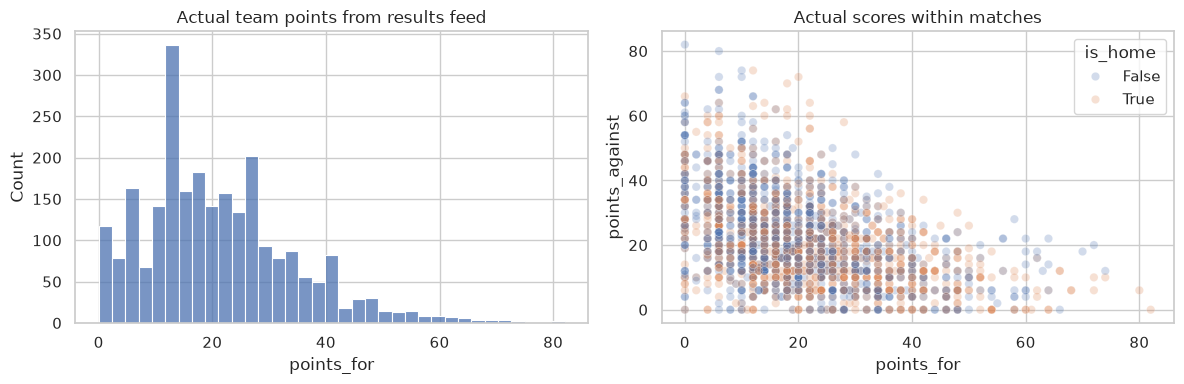

In [4]:
team_stats = players.groupby(['fixture_id','team_id'], as_index=False).agg(
    selected_players=('player_id','nunique'),
    tries=('tries','sum'), goals=('goals_made','sum'), drop_goals=('drop_goals','sum'),
    tackles=('tackles_made','sum'), missed_tackles=('tackles_missed','sum'),
)

fixture_results = results_raw[
    ['fixture_id', 'fixture_date', 'fixture_round', 'neutral_venue',
     'home_team', 'away_team', 'home_ft_score', 'away_ft_score']
]

home_team_match = fixture_results.rename(columns={
    'home_team': 'team_id',
    'away_team': 'opposition_id',
    'home_ft_score': 'points_for',
    'away_ft_score': 'points_against',
}).assign(is_home=True)

away_team_match = fixture_results.rename(columns={
    'away_team': 'team_id',
    'home_team': 'opposition_id',
    'away_ft_score': 'points_for',
    'home_ft_score': 'points_against',
}).assign(is_home=False)

scorelines = pd.concat([home_team_match, away_team_match], ignore_index=True)
team_match = team_stats.merge(
    scorelines,
    on=['fixture_id', 'team_id'],
    how='inner',
    validate='one_to_one',
)
assert len(team_match) == len(team_stats), 'Some team-match rows did not match the results feed'
assert not team_match.duplicated(['fixture_id','team_id']).any(), 'A fixture does not resolve to exactly two teams'
team_match['margin'] = team_match.points_for - team_match.points_against
assert team_match[['points_for', 'points_against', 'fixture_date', 'opposition_id']].notna().all().all(), 'Missing results values after merge'

display(team_match[['points_for','points_against','margin','selected_players']].describe())
display(team_match[['is_home','neutral_venue']].value_counts().to_frame('rows'))
fig, ax = plt.subplots(1,2,figsize=(12,4))
sns.histplot(team_match.points_for, bins=35, ax=ax[0]); ax[0].set_title('Actual team points from results feed')
sns.scatterplot(data=team_match, x='points_for', y='points_against', hue='is_home', alpha=.25, ax=ax[1]); ax[1].set_title('Actual scores within matches')
plt.tight_layout()

## 3. Primary position and availability
The CSV supplies numeric position codes but no dictionary. We therefore retain honest labels such as `Position 6`. Add a verified mapping below when available. Each player's primary position is their modal recorded code.

In [5]:
POSITION_MAP = {}  # Example after verification: {1: 'Fullback', 6: 'Stand-off'}
player_summary = players.groupby(['player_id','player_name'], as_index=False).agg(
    appearances=('fixture_id','nunique'), teams=('team_id','nunique'), total_points=('player_points','sum'))
primary_pos = (players.groupby('player_id').position_id
               .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan).rename('position_id'))
player_summary = player_summary.merge(primary_pos, on='player_id')
player_summary['position'] = player_summary.position_id.map(POSITION_MAP).fillna(
    'Position ' + player_summary.position_id.astype('Int64').astype(str))
display(player_summary.sort_values('appearances', ascending=False).head(20))

,player_id,player_name,appearances,teams,total_points,position_id,position
207,208,Ben Currie,184,1,136.000,12,Position 12
36,37,Zak Hardaker,179,4,786.000,3,Position 3
236,237,Tuimoala Lolohea,177,3,315.000,6,Position 6
131,132,Marc Sneyd,176,3,"1,285.000",7,Position 7
199,200,Toby King,174,3,264.000,4,Position 4
80,81,Daryl Clark,172,2,160.000,9,Position 9
172,173,Liam Farrell,172,1,228.000,12,Position 12
110,111,Ash Handley,172,1,396.000,5,Position 5
139,140,Chris Atkin,171,4,159.000,15,Position 15
135,136,Oliver Partington,168,3,48.000,13,Position 13


## 4. Regularised player attack and defence models
We create a sparse selected-player matrix and add team, opponent, and home/away fixed effects. Ridge shrinkage is essential because line-ups are correlated and some players have few appearances. The latest 20% of fixtures by actual fixture date is held out. Attack predicts points scored. Defence predicts points conceded; its player coefficients are multiplied by -1 so positive means points prevented.

In [6]:
eligible = player_summary.loc[player_summary.appearances >= MIN_APPEARANCES, 'player_id'].tolist()
pid_to_col = {pid:i for i,pid in enumerate(eligible)}
row_key = team_match.reset_index().rename(columns={'index':'tm_row'})[['fixture_id','team_id','tm_row']]
sel = players.merge(row_key, on=['fixture_id','team_id'], how='inner')
sel = sel[sel.player_id.isin(pid_to_col)]
P = sparse.csr_matrix((np.ones(len(sel)), (sel.tm_row, sel.player_id.map(pid_to_col))),
                      shape=(len(team_match), len(eligible)))

cats = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
C = cats.fit_transform(team_match[['team_id','opposition_id','is_home']])
X = sparse.hstack([C, P], format='csr')
order = np.argsort(team_match[ORDER_COL].to_numpy())
cut = int(len(order)*(1-TEST_FRACTION))
train_idx, test_idx = order[:cut], order[cut:]

def fit_rating_model(target):
    model = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
    model.fit(X[train_idx], team_match[target].to_numpy()[train_idx])
    pred = model.predict(X[test_idx])
    y = team_match[target].to_numpy()[test_idx]
    metrics = {'MAE': mean_absolute_error(y,pred), 'RMSE': mean_squared_error(y,pred)**0.5}
    return model, pred, metrics

attack_model, attack_pred, attack_metrics = fit_rating_model('points_for')
defence_model, defence_pred, defence_metrics = fit_rating_model('points_against')
display(pd.DataFrame([attack_metrics,defence_metrics], index=['attack','defence']))

,MAE,RMSE
attack,10.200,13.130
defence,9.551,12.693


In [7]:
n_cat = C.shape[1]
ratings = player_summary[player_summary.player_id.isin(eligible)].copy()
ratings['attack_rating'] = ratings.player_id.map({pid:attack_model.coef_[n_cat+i] for pid,i in pid_to_col.items()})
ratings['defence_rating'] = ratings.player_id.map({pid:-defence_model.coef_[n_cat+i] for pid,i in pid_to_col.items()})
ratings['overall_rating'] = ratings.attack_rating + ratings.defence_rating
ratings['reliability'] = np.minimum(1, np.sqrt(ratings.appearances / 40))
ratings['reliable_overall'] = ratings.overall_rating * ratings.reliability
ratings = ratings.sort_values('reliable_overall', ascending=False)
display(ratings[['player_name','position','appearances','attack_rating','defence_rating','overall_rating','reliability']].head(TOP_N))
ratings.to_csv('player_attack_defence_ratings.csv', index=False)

,player_name,position,appearances,attack_rating,defence_rating,overall_rating,reliability
312,Jake Trueman,Position 6,128,2.178,3.388,5.566,1.000
164,Bevan French,Position 6,132,2.996,2.201,5.197,1.000
245,Tom Whitehead,Position 18,35,3.376,2.030,5.405,0.935
39,Josh Charnley,Position 2,163,2.683,1.498,4.181,1.000
169,Tyler Dupree,Position 16,112,2.002,1.970,3.972,1.000
183,Tom Johnstone,Position 5,121,1.328,2.583,3.911,1.000
375,Richie Myler,Position 1,71,3.083,0.827,3.909,1.000
189,Julian Bousquet,Position 10,156,2.563,1.326,3.889,1.000
59,Jake Connor,Position 6,165,1.810,1.986,3.796,1.000
24,Sauaso Sue,Position 8,85,1.311,2.454,3.765,1.000


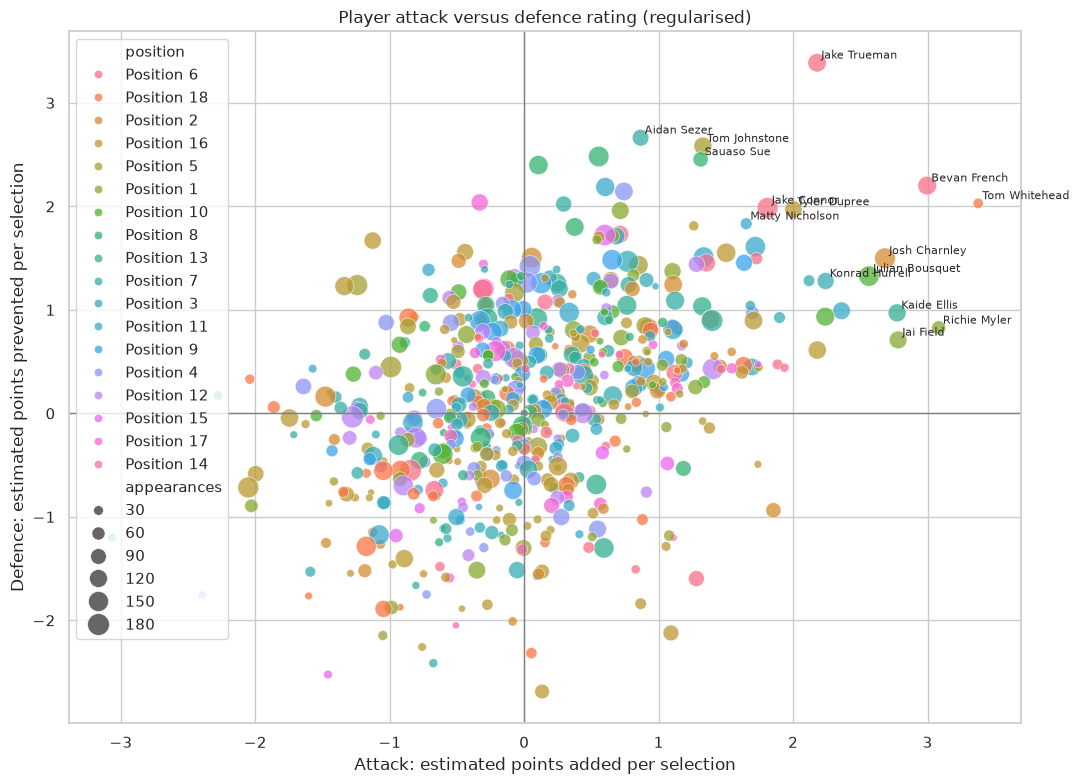

In [8]:
fig, ax = plt.subplots(figsize=(11,8))
sns.scatterplot(data=ratings, x='attack_rating', y='defence_rating', hue='position',
                size='appearances', sizes=(25,250), alpha=.75, ax=ax)
for _, r in ratings.head(15).iterrows():
    ax.annotate(r.player_name, (r.attack_rating,r.defence_rating), fontsize=8, xytext=(3,3), textcoords='offset points')
ax.axhline(0,color='grey',lw=1); ax.axvline(0,color='grey',lw=1)
ax.set_title('Player attack versus defence rating (regularised)')
ax.set_xlabel('Attack: estimated points added per selection')
ax.set_ylabel('Defence: estimated points prevented per selection')
plt.tight_layout()

## 6. Blend player selection into team strength

This section tests whether a fixture-specific team strength, built from the selected players' ratings, improves on the database strength multipliers that were already learned from recent results. The database values act as the prior; the player-derived signal is iteratively damped back into the baseline until the adjustment stabilises.

In [9]:
import sqlite3

DATABASE_PATH = Path('/workspaces/rugby_league_pricing/data/rugby_league_pricing.db')
assert DATABASE_PATH.exists(), f'Database not found: {DATABASE_PATH}'

FIXTURE_DATE_CORRECTIONS = {
    '10218': '2020-03-08',
}

with sqlite3.connect(DATABASE_PATH) as connection:
    db_strength = pd.read_sql_query(
        """
        SELECT
            fixture_id,
            match_date,
            season,
            team_id,
            opponent_id,
            is_home,
            scaled_attack_multiplier AS db_attack_multiplier,
            scaled_defence_multiplier AS db_defence_multiplier,
            attack_multiplier AS raw_attack_multiplier,
            defence_multiplier AS raw_defence_multiplier
        FROM strength_multipliers
        ORDER BY match_date, fixture_id, team_id
        """,
        connection,
        parse_dates=['match_date'],
    )
    db_expected = pd.read_sql_query(
        """
        SELECT
            fixture_id,
            match_date,
            season,
            home_team_id,
            away_team_id,
            league_average_points,
            home_scoring_factor,
            away_scoring_factor,
            home_attack_multiplier,
            home_defence_multiplier,
            away_attack_multiplier,
            away_defence_multiplier,
            expected_home_score,
            expected_away_score
        FROM expected_scores
        ORDER BY match_date, fixture_id
        """,
        connection,
        parse_dates=['match_date'],
    )
    canonical_fixtures = pd.read_sql_query(
        """
        SELECT
            fixture_id,
            match_date,
            home_team_id,
            away_team_id,
            competition_stage_id
        FROM fixtures
        """,
        connection,
        parse_dates=['match_date'],
    )
    teams = pd.read_sql_query(
        """
        SELECT
            team_id,
            canonical_name
        FROM teams
        """,
        connection,
    )
    team_source_mappings = pd.read_sql_query(
        """
        SELECT
            team_id,
            source_team_name,
            valid_from_season,
            valid_to_season
        FROM team_source_mappings
        WHERE source_name = 'patreon'
        """,
        connection,
    )

teams = teams.set_index('canonical_name')['team_id'].to_dict()
TEAM_NAME_FALLBACKS = {
    'York RLFC': 'York Knights',
    'Leigh Centurions': 'Leigh Leopards',
}

team_source_mappings['valid_from_season'] = team_source_mappings['valid_from_season'].astype('Int64')
team_source_mappings['valid_to_season'] = team_source_mappings['valid_to_season'].astype('Int64')
canonical_fixtures['match_date'] = pd.to_datetime(canonical_fixtures['match_date'], errors='raise').dt.normalize()
fixture_date_corrections = pd.to_datetime(
    pd.Series(FIXTURE_DATE_CORRECTIONS),
    errors='raise',
).dt.normalize()

def resolve_source_team_id(source_team_name, season):
    candidates = team_source_mappings[
        team_source_mappings.source_team_name.eq(source_team_name)
    ].copy()

    candidates = candidates[
        (candidates.valid_from_season.isna() | (candidates.valid_from_season <= season))
        & (candidates.valid_to_season.isna() | (candidates.valid_to_season >= season))
    ]

    if candidates.empty:
        lookup_name = source_team_name if source_team_name in teams else TEAM_NAME_FALLBACKS.get(source_team_name)
        if lookup_name is None or lookup_name not in teams:
            raise ValueError(
                f'No team mapping found for {source_team_name!r} in season {season}'
            )
        return int(teams[lookup_name])

    if len(candidates) > 1:
        candidates = candidates.sort_values(['valid_from_season', 'team_id'])

    return int(candidates.iloc[-1]['team_id'])

patreon_fixture_meta = results_raw[[
    'fixture_id',
    'fixture_date',
    'home_team',
    'away_team',
    'neutral_venue',
]].drop_duplicates().copy()
patreon_fixture_meta['fixture_date'] = pd.to_datetime(
    patreon_fixture_meta['fixture_date'],
    errors='raise',
).dt.normalize()
patreon_fixture_meta['season'] = patreon_fixture_meta.fixture_date.dt.year.astype(int)
patreon_fixture_meta['source_fixture_id'] = patreon_fixture_meta['fixture_id'].astype(str)
patreon_fixture_meta['fixture_date'] = patreon_fixture_meta['source_fixture_id'].map(
    fixture_date_corrections,
).fillna(patreon_fixture_meta['fixture_date'])
patreon_fixture_meta['home_team_id'] = patreon_fixture_meta.apply(
    lambda row: resolve_source_team_id(row.home_team, row.season),
    axis=1,
 )
patreon_fixture_meta['away_team_id'] = patreon_fixture_meta.apply(
    lambda row: resolve_source_team_id(row.away_team, row.season),
    axis=1,
 )
patreon_fixture_meta['exact_canonical_fixture_id'] = patreon_fixture_meta.apply(
    lambda row: f"{row.fixture_date.strftime('%Y-%m-%d')}_{row.home_team_id}_{row.away_team_id}",
    axis=1,
 )
patreon_fixture_meta['reversed_canonical_fixture_id'] = patreon_fixture_meta.apply(
    lambda row: f"{row.fixture_date.strftime('%Y-%m-%d')}_{row.away_team_id}_{row.home_team_id}",
    axis=1,
 )

canonical_fixture_ids = set(canonical_fixtures['fixture_id'].astype(str))
matched_fixture_rows = []
unresolved_fixture_rows = []

for row in patreon_fixture_meta.itertuples(index=False):
    if row.exact_canonical_fixture_id in canonical_fixture_ids:
        matched_fixture_rows.append({
            'source_fixture_id': row.source_fixture_id,
            'canonical_fixture_id': row.exact_canonical_fixture_id,
            'match_type': 'exact',
        })
        continue

    if row.reversed_canonical_fixture_id in canonical_fixture_ids:
        matched_fixture_rows.append({
            'source_fixture_id': row.source_fixture_id,
            'canonical_fixture_id': row.reversed_canonical_fixture_id,
            'match_type': 'reversed',
        })
        continue

    unresolved_fixture_rows.append({
        'source_fixture_id': row.source_fixture_id,
        'fixture_date': row.fixture_date,
        'season': row.season,
        'home_team': row.home_team,
        'away_team': row.away_team,
        'home_team_id': row.home_team_id,
        'away_team_id': row.away_team_id,
    })

fixture_mapping = pd.DataFrame(matched_fixture_rows)
unresolved_fixtures = pd.DataFrame(unresolved_fixture_rows)

if not unresolved_fixtures.empty:
    display(unresolved_fixtures.head(TOP_N))
    raise ValueError(
        f'Could not resolve canonical fixture IDs for {len(unresolved_fixtures)} Patreon fixtures'
    )

team_match_db = team_match.copy()
team_match_db['season'] = team_match_db.fixture_date.dt.year.astype(int)
team_match_db['source_fixture_id'] = team_match_db['fixture_id'].astype(str)
team_match_db = team_match_db.merge(
    fixture_mapping,
    on='source_fixture_id',
    how='left',
    validate='many_to_one',
)

assert team_match_db['canonical_fixture_id'].notna().all(), 'Missing canonical fixture mapping for one or more Patreon fixtures'

team_match_db['team_id_num'] = team_match_db.apply(
    lambda row: resolve_source_team_id(row.team_id, row.season),
    axis=1,
 )
team_match_db['opponent_id_num'] = team_match_db.apply(
    lambda row: resolve_source_team_id(row.opposition_id, row.season),
    axis=1,
 )

db_strength_for_merge = db_strength[
    [
        'fixture_id',
        'team_id',
        'opponent_id',
        'db_attack_multiplier',
        'db_defence_multiplier',
        'raw_attack_multiplier',
        'raw_defence_multiplier',
    ]
].rename(
    columns={'team_id': 'team_id_num', 'opponent_id': 'opponent_id_num'}
)

team_match_db = team_match_db.merge(
    db_strength_for_merge,
    left_on=['canonical_fixture_id', 'team_id_num', 'opponent_id_num'],
    right_on=['fixture_id', 'team_id_num', 'opponent_id_num'],
    how='left',
    validate='one_to_one',
)

assert team_match_db[['db_attack_multiplier', 'db_defence_multiplier']].notna().all().all(), 'Missing database strength multipliers after merge'

team_match_db = team_match_db.merge(
    db_expected[
        [
            'fixture_id',
            'league_average_points',
            'home_scoring_factor',
            'away_scoring_factor',
            'expected_home_score',
            'expected_away_score',
        ]
    ],
left_on='canonical_fixture_id',
    right_on='fixture_id',
    how='left',
    validate='many_to_one',
)

team_match_db['db_expected_points'] = np.where(
    team_match_db['is_home'],
    team_match_db['expected_home_score'],
    team_match_db['expected_away_score'],
)

baseline_metrics = pd.Series({
    'MAE': mean_absolute_error(team_match_db['points_for'], team_match_db['db_expected_points']),
    'RMSE': mean_squared_error(team_match_db['points_for'], team_match_db['db_expected_points']) ** 0.5,
})

display(baseline_metrics.to_frame('db_expected_baseline'))
display(team_match_db[[
    'source_fixture_id',
    'canonical_fixture_id',
    'team_id',
    'opposition_id',
    'is_home',
    'points_for',
    'db_expected_points',
    'db_attack_multiplier',
    'db_defence_multiplier',
]].head(TOP_N))

,db_expected_baseline
MAE,9.902
RMSE,12.494


,source_fixture_id,canonical_fixture_id,team_id,opposition_id,is_home,points_for,db_expected_points,db_attack_multiplier,db_defence_multiplier
0,10001,2019-01-31_9_8,St Helens,Wigan Warriors,True,22,21.725,1.154,0.830
1,10001,2019-01-31_9_8,Wigan Warriors,St Helens,False,12,16.444,0.904,0.713
2,10002,2019-02-01_11_10,Hull FC,Hull Kingston Rovers,False,16,19.052,0.833,1.265
3,10002,2019-02-01_11_10,Hull Kingston Rovers,Hull FC,True,18,38.177,1.142,1.044
4,10003,2019-02-01_5_12,Huddersfield Giants,Salford Red Devils,True,14,27.888,0.873,1.081
5,10003,2019-02-01_5_12,Salford Red Devils,Huddersfield Giants,False,34,21.554,0.910,1.209
6,10004,2019-02-01_7_13,Castleford Tigers,Catalans Dragons,True,20,29.845,1.016,0.823
7,10004,2019-02-01_7_13,Catalans Dragons,Castleford Tigers,False,4,16.874,0.936,1.112
8,10005,2019-02-02_14_2,Leeds Rhinos,Warrington Wolves,False,6,18.823,0.889,1.186
9,10005,2019-02-02_14_2,Warrington Wolves,Leeds Rhinos,True,26,27.888,0.890,0.967


In [10]:
rating_lookup = ratings.set_index('player_id')[['attack_rating', 'defence_rating', 'reliability', 'overall_rating', 'position_id']].copy()
rating_lookup['position_id'] = pd.to_numeric(rating_lookup['position_id'], errors='coerce').astype('Int64')

# Normalize fixture/team keys so lineup lookups cannot miss because of dtype mismatches.
players_for_lookup = players[['fixture_id', 'team_id', 'player_id']].copy()
players_for_lookup['source_fixture_id'] = players_for_lookup['fixture_id'].astype(str)
players_for_lookup['team_id_key'] = players_for_lookup['team_id'].astype(str)
selected_players = players_for_lookup.groupby(['source_fixture_id', 'team_id_key']).player_id.agg(set).to_dict()

KEY_POSITION_GROUPS = {
    'props_8_10': {8, 10},
    'middle_pack_8_10_11_12_13': {8, 10, 11, 12, 13},
    'halves_6_7': {6, 7},
    'spine_1_6_7_9': {1, 6, 7, 9},
    'combo_1_7': {1, 7},
    'combo_1_6': {1, 6},
    'hooker_9': {9},
    'stand_off_6': {6},
    'scrum_half_7': {7},
}

def _weighted_sum(values, weights):
    if len(values) == 0:
        return 0.0
    if weights is None:
        return float(values.sum())
    return float((values * weights).sum())

def summarize_lineup_strength(source_fixture_id, team_name):
    key = (str(source_fixture_id), str(team_name))
    ids = selected_players.get(key, set())
    frame = rating_lookup.loc[rating_lookup.index.intersection(ids)].copy()

    base = {
        'selected_player_count': 0,
        'player_attack_signal': 0.0,
        'player_defence_signal': 0.0,
        'player_strength_signal': 0.0,
        'player_reliability_mean': 0.0,
        'top5_strength_on_field': 0.0,
    }
    for group_name in KEY_POSITION_GROUPS:
        base[f'{group_name}_strength'] = 0.0

    if frame.empty:
        return pd.Series(base)

    weights = frame['reliability'].fillna(0).clip(lower=0)
    if float(weights.sum()) <= 0:
        weights = None

    attack_signal = _weighted_sum(frame['attack_rating'].fillna(0), weights)
    defence_signal = _weighted_sum(frame['defence_rating'].fillna(0), weights)

    out = dict(base)
    out['selected_player_count'] = int(len(frame))
    out['player_attack_signal'] = attack_signal
    out['player_defence_signal'] = defence_signal
    out['player_strength_signal'] = attack_signal + defence_signal
    out['player_reliability_mean'] = float(frame['reliability'].mean())

    top5 = frame.sort_values('overall_rating', ascending=False).head(5)
    top5_weights = top5['reliability'].fillna(0).clip(lower=0)
    if float(top5_weights.sum()) <= 0:
        top5_weights = None
    out['top5_strength_on_field'] = _weighted_sum(top5['overall_rating'].fillna(0), top5_weights)

    pos_series = frame['position_id']
    for group_name, group_positions in KEY_POSITION_GROUPS.items():
        in_group = pos_series.isin(group_positions)
        group_frame = frame.loc[in_group]
        group_weights = group_frame['reliability'].fillna(0).clip(lower=0)
        if float(group_weights.sum()) <= 0:
            group_weights = None
        out[f'{group_name}_strength'] = _weighted_sum(group_frame['overall_rating'].fillna(0), group_weights)

    return pd.Series(out)

def summarize_missing_core(source_fixture_id, team_name, missing_ids):
    base = {
        'core_player_pool_size': 0,
        'missing_core_count': 0,
        'missing_core_overall_sum': 0.0,
        'missing_core_top3_sum': 0.0,
    }
    for group_name in KEY_POSITION_GROUPS:
        base[f'missing_{group_name}_sum'] = 0.0

    if not missing_ids:
        return pd.Series(base)

    frame = rating_lookup.loc[rating_lookup.index.intersection(list(missing_ids))].copy()
    if frame.empty:
        return pd.Series(base)

    frame['overall_pos'] = frame['overall_rating'].clip(lower=0)
    out = dict(base)
    out['missing_core_count'] = int(len(frame))
    out['missing_core_overall_sum'] = float(frame['overall_pos'].sum())
    out['missing_core_top3_sum'] = float(frame['overall_pos'].sort_values(ascending=False).head(3).sum())

    for group_name, group_positions in KEY_POSITION_GROUPS.items():
        out[f'missing_{group_name}_sum'] = float(
            frame.loc[frame['position_id'].isin(group_positions), 'overall_pos'].sum()
        )

    return pd.Series(out)

team_strength_test = team_match_db.copy()
team_strength_test['source_fixture_id'] = team_strength_test['source_fixture_id'].astype(str)
team_strength_test['team_id_key'] = team_strength_test['team_id'].astype(str)

lineup_strength = team_strength_test.apply(
    lambda row: summarize_lineup_strength(row.source_fixture_id, row.team_id_key),
    axis=1,
 )
team_strength_test = pd.concat([team_strength_test, lineup_strength], axis=1)

# Build rolling core absences: players seen at least 3 times in prior 8 matches for that team.
history_by_team = {}
missing_rows = []
chronological = team_strength_test.sort_values([ORDER_COL, 'source_fixture_id', 'team_id_key']).copy()

for row in chronological.itertuples(index=False):
    team_key = row.team_id_key
    fixture_key = row.source_fixture_id
    selected_now = selected_players.get((fixture_key, team_key), set())

    prior_sets = history_by_team.get(team_key, [])[-8:]
    counts = {}
    for s in prior_sets:
        for pid in s:
            counts[pid] = counts.get(pid, 0) + 1

    core_players = {pid for pid, n in counts.items() if n >= 3}
    missing_core = core_players - selected_now

    missing_metrics = summarize_missing_core(fixture_key, team_key, missing_core).to_dict()
    missing_metrics['core_player_pool_size'] = int(len(core_players))
    missing_metrics['source_fixture_id'] = fixture_key
    missing_metrics['team_id_key'] = team_key
    missing_rows.append(missing_metrics)

    history_by_team.setdefault(team_key, []).append(selected_now)

missing_frame = pd.DataFrame(missing_rows)
team_strength_test = team_strength_test.merge(
    missing_frame,
    on=['source_fixture_id', 'team_id_key'],
    how='left',
    validate='one_to_one',
)

# Attach opponent features inside each fixture.
opponent_columns = [
    'canonical_fixture_id',
    'team_id',
    'player_strength_signal',
    'top5_strength_on_field',
    'halves_6_7_strength',
    'spine_1_6_7_9_strength',
    'missing_core_overall_sum',
    'missing_core_top3_sum',
    'missing_halves_6_7_sum',
    'missing_spine_1_6_7_9_sum',
]

opponent_features = team_strength_test[opponent_columns].rename(
    columns={
        'team_id': 'opposition_id',
        'player_strength_signal': 'opponent_player_strength_signal',
        'top5_strength_on_field': 'opponent_top5_strength_on_field',
        'halves_6_7_strength': 'opponent_halves_6_7_strength',
        'spine_1_6_7_9_strength': 'opponent_spine_1_6_7_9_strength',
        'missing_core_overall_sum': 'opponent_missing_core_overall_sum',
        'missing_core_top3_sum': 'opponent_missing_core_top3_sum',
        'missing_halves_6_7_sum': 'opponent_missing_halves_6_7_sum',
        'missing_spine_1_6_7_9_sum': 'opponent_missing_spine_1_6_7_9_sum',
    }
)

team_strength_test = team_strength_test.merge(
    opponent_features,
    on=['canonical_fixture_id', 'opposition_id'],
    how='left',
    validate='many_to_one',
)

signal_cols = [
    'player_attack_signal',
    'player_defence_signal',
    'player_strength_signal',
    'top5_strength_on_field',
    'props_8_10_strength',
    'middle_pack_8_10_11_12_13_strength',
    'halves_6_7_strength',
    'spine_1_6_7_9_strength',
    'combo_1_7_strength',
    'combo_1_6_strength',
    'hooker_9_strength',
    'stand_off_6_strength',
    'scrum_half_7_strength',
    'missing_core_overall_sum',
    'missing_core_top3_sum',
    'missing_props_8_10_sum',
    'missing_middle_pack_8_10_11_12_13_sum',
    'missing_halves_6_7_sum',
    'missing_spine_1_6_7_9_sum',
    'missing_combo_1_7_sum',
    'missing_combo_1_6_sum',
    'missing_hooker_9_sum',
    'missing_stand_off_6_sum',
    'missing_scrum_half_7_sum',
    'opponent_player_strength_signal',
    'opponent_top5_strength_on_field',
    'opponent_halves_6_7_strength',
    'opponent_spine_1_6_7_9_strength',
    'opponent_missing_core_overall_sum',
    'opponent_missing_core_top3_sum',
    'opponent_missing_halves_6_7_sum',
    'opponent_missing_spine_1_6_7_9_sum',
]

for col in signal_cols:
    team_strength_test[col] = team_strength_test[col].fillna(0.0)
    std = team_strength_test[col].std(ddof=0)
    if std == 0:
        team_strength_test[f'{col}_z'] = 0.0
    else:
        team_strength_test[f'{col}_z'] = (team_strength_test[col] - team_strength_test[col].mean()) / std

# Disruption flags to capture heavy-loss games.
missing_top3_threshold = team_strength_test['missing_core_top3_sum'].quantile(0.80)
missing_halves_threshold = team_strength_test['missing_halves_6_7_sum'].quantile(0.80)
team_strength_test['high_disruption_flag'] = (
    (team_strength_test['missing_core_top3_sum'] >= missing_top3_threshold)
    | (team_strength_test['missing_halves_6_7_sum'] >= missing_halves_threshold)
).astype(int)

team_strength_test['baseline_expected_points'] = team_strength_test['db_expected_points'].clip(lower=0.5)

feature_cols = [
    'player_strength_signal_z',
    'top5_strength_on_field_z',
    'props_8_10_strength_z',
    'middle_pack_8_10_11_12_13_strength_z',
    'halves_6_7_strength_z',
    'spine_1_6_7_9_strength_z',
    'hooker_9_strength_z',
    'stand_off_6_strength_z',
    'scrum_half_7_strength_z',
    'missing_core_overall_sum_z',
    'missing_core_top3_sum_z',
    'missing_props_8_10_sum_z',
    'missing_middle_pack_8_10_11_12_13_sum_z',
    'missing_halves_6_7_sum_z',
    'missing_spine_1_6_7_9_sum_z',
    'missing_hooker_9_sum_z',
    'missing_stand_off_6_sum_z',
    'missing_scrum_half_7_sum_z',
    'opponent_player_strength_signal_z',
    'opponent_top5_strength_on_field_z',
    'opponent_halves_6_7_strength_z',
    'opponent_spine_1_6_7_9_strength_z',
    'opponent_missing_core_overall_sum_z',
    'opponent_missing_core_top3_sum_z',
    'opponent_missing_halves_6_7_sum_z',
    'opponent_missing_spine_1_6_7_9_sum_z',
    'high_disruption_flag',
    'is_home',
]

# Genuine walk-forward validation: train on all data before each cutoff date and
# evaluate on the next fixture date only. This matches a production forecasting setup,
# because the model never sees information from the evaluation date or later.
chronological = team_strength_test.sort_values(ORDER_COL).copy()
cutoff_dates = sorted(chronological[ORDER_COL].drop_duplicates().tolist())
min_train_fixtures = max(50, int(0.15 * len(chronological)))
walkforward_rows = []

for cutoff_index in range(min_train_fixtures, len(cutoff_dates) - 1):
    cutoff_date = cutoff_dates[cutoff_index]
    train = chronological[chronological[ORDER_COL] < cutoff_date].copy()
    test = chronological[chronological[ORDER_COL] == cutoff_date].copy()
    if train.empty or test.empty:
        continue
    if len(train) < min_train_fixtures:
        continue

    train_target = np.log(
        (train['points_for'] + 0.5) / train['baseline_expected_points'].clip(lower=1e-6)
    )
    model = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
    model.fit(train[feature_cols], train_target)

    test_pred = model.predict(test[feature_cols])
    test = test.copy()
    test['player_expected_points'] = test['baseline_expected_points'] * np.exp(test_pred)

    baseline_mae = mean_absolute_error(test['points_for'], test['baseline_expected_points'])
    baseline_rmse = np.sqrt(mean_squared_error(test['points_for'], test['baseline_expected_points']))
    player_mae = mean_absolute_error(test['points_for'], test['player_expected_points'])
    player_rmse = np.sqrt(mean_squared_error(test['points_for'], test['player_expected_points']))

    walkforward_rows.append({
        'cutoff_date': cutoff_date,
        'train_fixtures': int(len(train)),
        'test_fixtures': int(len(test)),
        'baseline_mae': float(baseline_mae),
        'player_mae': float(player_mae),
        'mae_gain': float(baseline_mae - player_mae),
        'baseline_rmse': float(baseline_rmse),
        'player_rmse': float(player_rmse),
        'rmse_gain': float(baseline_rmse - player_rmse),
    })

if walkforward_rows:
    walkforward = pd.DataFrame(walkforward_rows)
    display(walkforward.head(10))
    display(walkforward[['baseline_mae', 'player_mae', 'baseline_rmse', 'player_rmse']].mean().to_frame('mean_metric'))
    print('Walk-forward MAE improvement:', walkforward['mae_gain'].mean())
    print('Walk-forward RMSE improvement:', walkforward['rmse_gain'].mean())
else:
    print('No walk-forward folds were evaluated. Increase the minimum training-window length or check the date coverage.')

# Position-aware shrinkage variant: apply an additional penalty to lower-confidence
# position groups by scaling their features before fitting the same Ridge model.
# This keeps the comparison fair because the train/test folds and target are identical;
# only the regularisation profile changes.
position_shrink_scale = {
    'props_8_10_strength_z': 0.80,
    'middle_pack_8_10_11_12_13_strength_z': 0.85,
    'hooker_9_strength_z': 0.90,
    'stand_off_6_strength_z': 0.90,
    'scrum_half_7_strength_z': 0.90,
    'missing_props_8_10_sum_z': 0.80,
    'missing_middle_pack_8_10_11_12_13_sum_z': 0.85,
    'missing_hooker_9_sum_z': 0.90,
    'missing_stand_off_6_sum_z': 0.90,
    'missing_scrum_half_7_sum_z': 0.90,
    'high_disruption_flag': 0.95,
}

shrink_rows = []
for cutoff_index in range(min_train_fixtures, len(cutoff_dates) - 1):
    cutoff_date = cutoff_dates[cutoff_index]
    train = chronological[chronological[ORDER_COL] < cutoff_date].copy()
    test = chronological[chronological[ORDER_COL] == cutoff_date].copy()
    if train.empty or test.empty:
        continue
    if len(train) < min_train_fixtures:
        continue

    train_target = np.log(
        (train['points_for'] + 0.5) / train['baseline_expected_points'].clip(lower=1e-6)
    )
    train_features = train[feature_cols].copy()
    test_features = test[feature_cols].copy()
    for column, scale in position_shrink_scale.items():
        if column in train_features.columns:
            train_features[column] = train_features[column] * scale
            test_features[column] = test_features[column] * scale

    model_shrunk = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
    model_shrunk.fit(train_features, train_target)
    test_pred_shrunk = model_shrunk.predict(test_features)
    shrunk_expected = test['baseline_expected_points'] * np.exp(test_pred_shrunk)

    baseline_mae = mean_absolute_error(test['points_for'], test['baseline_expected_points'])
    baseline_rmse = np.sqrt(mean_squared_error(test['points_for'], test['baseline_expected_points']))
    shrunk_mae = mean_absolute_error(test['points_for'], shrunk_expected)
    shrunk_rmse = np.sqrt(mean_squared_error(test['points_for'], shrunk_expected))

    shrink_rows.append({
        'cutoff_date': cutoff_date,
        'train_fixtures': int(len(train)),
        'test_fixtures': int(len(test)),
        'baseline_mae': float(baseline_mae),
        'shrunken_mae': float(shrunk_mae),
        'mae_gain': float(baseline_mae - shrunk_mae),
        'baseline_rmse': float(baseline_rmse),
        'shrunken_rmse': float(shrunk_rmse),
        'rmse_gain': float(baseline_rmse - shrunk_rmse),
    })

if shrink_rows:
    shrink_summary = pd.DataFrame(shrink_rows)
    display(shrink_summary.head(10))
    display(shrink_summary[['baseline_mae', 'shrunken_mae', 'baseline_rmse', 'shrunken_rmse']].mean().to_frame('mean_metric'))
    print('Position-shrinkage MAE improvement:', shrink_summary['mae_gain'].mean())
    print('Position-shrinkage RMSE improvement:', shrink_summary['rmse_gain'].mean())
else:
    print('No position-shrinkage folds were evaluated.')

order = np.argsort(team_strength_test[ORDER_COL].to_numpy())
cut = int(len(order) * (1 - TEST_FRACTION))
train_idx, test_idx = order[:cut], order[cut:]

current_adjustment = pd.Series(0.0, index=team_strength_test.index)
iteration_history = []
coef_tables = []

for iteration in range(1, 8):
    target = np.log((
        team_strength_test['points_for'] + 0.5
    ) / team_strength_test['baseline_expected_points']) - current_adjustment

    model = Ridge(alpha=0.75, fit_intercept=True)
    model.fit(team_strength_test.iloc[train_idx][feature_cols], target.iloc[train_idx])

    predicted_adjustment = pd.Series(
        model.predict(team_strength_test[feature_cols]),
        index=team_strength_test.index,
    )

    updated_adjustment = 0.6 * current_adjustment + 0.4 * predicted_adjustment
    max_delta = float((updated_adjustment - current_adjustment).abs().max())
    current_adjustment = updated_adjustment

    team_strength_test['blended_expected_points'] = (
        team_strength_test['baseline_expected_points'] * np.exp(current_adjustment)
    )
    team_strength_test['blended_attack_multiplier'] = (
        team_strength_test['db_attack_multiplier'] * np.exp(current_adjustment)
    )
    team_strength_test['blended_defence_multiplier'] = (
        team_strength_test['db_defence_multiplier'] / np.exp(current_adjustment)
    )

    train_pred = pd.Series(
        team_strength_test['baseline_expected_points'] * np.exp(predicted_adjustment),
        index=team_strength_test.index,
    )

    coef_frame = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': model.coef_,
        'abs_coefficient': np.abs(model.coef_),
        'iteration': iteration,
    }).sort_values('abs_coefficient', ascending=False)
    coef_tables.append(coef_frame)

    iteration_history.append({
        'iteration': iteration,
        'max_delta': max_delta,
        'train_mae': mean_absolute_error(
            team_strength_test['points_for'].iloc[train_idx],
            train_pred.iloc[train_idx],
        ),
        'test_mae': mean_absolute_error(
            team_strength_test['points_for'].iloc[test_idx],
            team_strength_test['blended_expected_points'].iloc[test_idx],
        ),
        'test_rmse': mean_squared_error(
            team_strength_test['points_for'].iloc[test_idx],
            team_strength_test['blended_expected_points'].iloc[test_idx],
        ) ** 0.5,
        'coefficient_l1': float(np.abs(model.coef_).sum()),
    })

    if max_delta < 0.0005:
        break

blended_metrics = pd.Series({
    'MAE': mean_absolute_error(
        team_strength_test['points_for'].iloc[test_idx],
        team_strength_test['blended_expected_points'].iloc[test_idx],
    ),
    'RMSE': mean_squared_error(
        team_strength_test['points_for'].iloc[test_idx],
        team_strength_test['blended_expected_points'].iloc[test_idx],
    ) ** 0.5,
})

signal_diagnostics = pd.DataFrame({
    'feature': signal_cols,
    'non_zero_rate': [float((team_strength_test[c].abs() > 1e-9).mean()) for c in signal_cols],
    'std': [float(team_strength_test[c].std(ddof=0)) for c in signal_cols],
}).sort_values(['non_zero_rate', 'std'], ascending=[False, False])

latest_coefs = coef_tables[-1].copy()

display(pd.DataFrame(iteration_history))
display(pd.concat([baseline_metrics.rename('db_baseline'), blended_metrics.rename('player_blended')], axis=1))
display(signal_diagnostics.head(20))
display(latest_coefs.head(20))

display(team_strength_test[[
    'source_fixture_id',
    'canonical_fixture_id',
    'team_id',
    'opposition_id',
    'is_home',
    'points_for',
    'baseline_expected_points',
    'blended_expected_points',
    'player_strength_signal',
    'halves_6_7_strength',
    'spine_1_6_7_9_strength',
    'missing_core_overall_sum',
    'missing_core_top3_sum',
    'missing_halves_6_7_sum',
    'missing_spine_1_6_7_9_sum',
    'high_disruption_flag',
]].sort_values(['missing_core_top3_sum', 'missing_halves_6_7_sum'], ascending=False).head(TOP_N))

,cutoff_date,train_fixtures,test_fixtures,baseline_mae,player_mae,mae_gain,baseline_rmse,player_rmse,rmse_gain
0,2023-06-24,1358,2,9.674,17.077,-7.404,9.914,17.284,-7.370
1,2023-06-25,1360,2,16.893,14.544,2.349,20.220,16.107,4.113
2,2023-06-29,1362,2,14.138,12.131,2.007,15.467,12.131,3.336
3,2023-06-30,1364,8,12.740,11.695,1.045,13.424,13.867,-0.443
4,2023-07-01,1372,2,5.219,2.273,2.946,6.879,2.893,3.986
5,2023-07-07,1374,6,2.844,6.192,-3.348,3.405,7.357,-3.952
6,2023-07-08,1380,2,17.312,15.877,1.435,19.781,16.049,3.732
7,2023-07-09,1382,4,10.826,8.278,2.548,11.130,8.670,2.460
8,2023-07-13,1386,2,12.430,4.712,7.718,12.586,5.779,6.806
9,2023-07-14,1388,6,9.506,5.534,3.972,11.138,6.585,4.553


,mean_metric
baseline_mae,10.068
player_mae,8.948
baseline_rmse,11.554
player_rmse,10.573


Walk-forward MAE improvement: 1.1191682796489457
Walk-forward RMSE improvement: 0.9806873980601414


,cutoff_date,train_fixtures,test_fixtures,baseline_mae,shrunken_mae,mae_gain,baseline_rmse,shrunken_rmse,rmse_gain
0,2023-06-24,1358,2,9.674,17.065,-7.392,9.914,17.272,-7.358
1,2023-06-25,1360,2,16.893,14.530,2.363,20.220,16.056,4.164
2,2023-06-29,1362,2,14.138,12.064,2.074,15.467,12.064,3.403
3,2023-06-30,1364,8,12.740,11.658,1.082,13.424,13.822,-0.399
4,2023-07-01,1372,2,5.219,2.282,2.937,6.879,2.893,3.985
5,2023-07-07,1374,6,2.844,6.162,-3.318,3.405,7.349,-3.944
6,2023-07-08,1380,2,17.312,15.898,1.413,19.781,16.073,3.708
7,2023-07-09,1382,4,10.826,8.230,2.596,11.130,8.622,2.507
8,2023-07-13,1386,2,12.430,4.710,7.720,12.586,5.786,6.799
9,2023-07-14,1388,6,9.506,5.551,3.954,11.138,6.596,4.542


,mean_metric
baseline_mae,10.068
shrunken_mae,8.945
baseline_rmse,11.554
shrunken_rmse,10.569


...

,iteration,max_delta,train_mae,test_mae,test_rmse,coefficient_l1
0,1,0.777,8.414,9.414,12.347,1.360
1,2,0.155,8.148,9.402,12.388,0.817
2,3,0.031,8.217,9.403,12.400,0.708
3,4,0.006,8.235,9.404,12.403,0.686
4,5,0.001,8.238,9.404,12.403,0.682
5,6,0.000,8.239,9.404,12.403,0.681


,db_baseline,player_blended
MAE,9.902,9.404
RMSE,12.494,12.403


,feature,non_zero_rate,std
2,player_strength_signal,1.000,8.887
24,opponent_player_strength_signal,1.000,8.887
1,player_defence_signal,1.000,5.536
0,player_attack_signal,1.000,4.032
3,top5_strength_on_field,1.000,3.926
25,opponent_top5_strength_on_field,1.000,3.926
5,middle_pack_8_10_11_12_13_strength,0.998,3.909
7,spine_1_6_7_9_strength,0.996,3.904
27,opponent_spine_1_6_7_9_strength,0.996,3.904
8,combo_1_7_strength,0.961,2.257


,feature,coefficient,abs_coefficient,iteration
18,opponent_player_strength_signal_z,-0.163,0.163,6
0,player_strength_signal_z,0.092,0.092,6
1,top5_strength_on_field_z,0.039,0.039,6
9,missing_core_overall_sum_z,-0.037,0.037,6
10,missing_core_top3_sum_z,-0.035,0.035,6
3,middle_pack_8_10_11_12_13_strength_z,-0.032,0.032,6
5,spine_1_6_7_9_strength_z,-0.029,0.029,6
26,high_disruption_flag,0.026,0.026,6
11,missing_props_8_10_sum_z,-0.026,0.026,6
22,opponent_missing_core_overall_sum_z,0.025,0.025,6


,source_fixture_id,canonical_fixture_id,team_id,opposition_id,is_home,points_for,baseline_expected_points,blended_expected_points,player_strength_signal,halves_6_7_strength,spine_1_6_7_9_strength,missing_core_overall_sum,missing_core_top3_sum,missing_halves_6_7_sum,missing_spine_1_6_7_9_sum,high_disruption_flag
1143,10576,2022-08-29_11_8,Wigan Warriors,Hull Kingston Rovers,False,28,28.296,18.551,0.521,0.000,0.000,23.809,12.431,6.000,12.455,1
1855,10933,2025-02-21_14_13,Warrington Wolves,Catalans Dragons,True,18,33.681,27.833,5.211,-1.607,1.954,14.300,11.961,1.504,1.921,1
1872,10942,2025-03-01_8_14,Warrington Wolves,Wigan Warriors,False,24,15.651,8.207,5.833,-1.607,2.235,13.882,11.961,1.504,1.504,1
1885,10948,2025-03-09_14_4,Warrington Wolves,Wakefield Trinity,True,16,30.550,18.196,1.176,-1.607,2.031,17.616,11.961,1.504,1.544,1
1337,10673,2023-06-04_10_14,Warrington Wolves,Hull FC,False,18,20.793,16.887,1.762,2.050,5.394,12.076,10.823,0.000,0.000,1
2045,11028,2025-07-10_10_4,Wakefield Trinity,Hull FC,False,10,18.685,13.669,11.424,-0.059,3.911,10.713,10.713,5.566,5.566,1
495,10248,2020-09-30_2_13,Leeds Rhinos,Catalans Dragons,True,6,25.704,11.117,-5.248,-0.979,-2.602,20.611,10.652,4.452,8.924,1
516,10259,2020-10-13_14_2,Leeds Rhinos,Warrington Wolves,False,6,20.687,10.004,-4.496,-0.979,-2.602,20.611,10.652,4.452,8.924,1
528,10265,2020-10-23_9_2,Leeds Rhinos,St Helens,False,8,15.745,6.120,-6.892,-0.979,-2.602,19.180,10.652,4.452,8.924,1
444,10223,2020-08-09_2_9,Leeds Rhinos,St Helens,True,0,29.461,14.352,2.397,0.250,0.813,12.747,10.652,3.223,7.132,1


## 3. Walk-forward validation: the real production gate

A final 20% hold-out is useful for quick inspection, but it is not the production test. The production question is: if I had only data up to each fixture date, would the player model improve expected points prediction on the next fixtures?

The code below runs an expanding-window backtest:

- sort fixtures by `fixture_date`
- train on all data before a cutoff,
- score the next chunk of fixtures,
- repeat forward in time
- compare baseline MAE/RMSE to player-adjusted MAE/RMSE

This is the same logic we would use in production and it avoids future leakage.

### Ridge in plain English

The ridge model is solving a penalised least-squares problem:

$$
\hat{\beta} = \arg\min_\beta \|y - X\beta\|_2^2 + \alpha \|\beta\|_2^2
$$

The extra $\alpha \|\beta\|_2^2$ term shrinks noisy player coefficients toward zero. That prevents a player with a short history or a noisy lineup sample from looking unrealistically strong or weak. The key idea is that we want stable player effects, not overfit ones.

### What the coefficients actually are

In ridge, each coefficient is a learned weight for one feature. If we write the model as:

$y = b_0 + b_1 x_1 + b_2 x_2 + ... + b_k x_k$

then each $b_j$ is a coefficient. It tells us how much the model thinks the prediction changes when feature $x_j$ moves by one unit.

A rugby-specific example is clearer:

- $x_1$ = player strength signal
- $x_2$ = missing-core disruption signal
- $x_3$ = opponent strength signal

Suppose the fitted coefficients are:

- $b_1 = 0.90$
- $b_2 = -1.40$
- $b_3 = 0.35$

Then the model is saying:

$y = b_0 + 0.90 	imes playerstrength - 1.40 	imes missingcore + 0.35 	imes opponentstrength$

So if a team has one more key player missing, the model reduces expected points by roughly 1.4. If the player strength signal increases by 1, expected points goes up by 0.9. These are not predicted points themselves; they are the weights the model learned for each feature.

### What the iteration table is checking

The iteration table is not the final answer. It is a convergence check: it shows how the coefficient list changes from one training pass to the next.

- `coef_update_size`: the biggest single change between one coefficient list and the next. If this is tiny, the model has mostly settled.
- `total_abs_coef`: the sum of the absolute values of all coefficients. This is a rough measure of how large the fitted weights are overall. It tells us about the model scale, not the model quality.

Worked example:

Suppose the coefficient list at iteration 1 is `[0.90, -1.40, 0.35]` and at iteration 2 it is `[0.95, -1.25, 0.32]`. The biggest move is 0.15, so `coef_update_size` is 0.15. The total absolute size in iteration 2 is `|0.95| + |-1.25| + |0.32| = 2.52`, so `total_abs_coef` is 2.52.

This tells us the model is still moving a bit, but not wildly. The real decision is still based on MAE/RMSE: did the model predict better? The coefficient table only tells us whether the fit has stabilised.

### Worked example

Imagine a player appears in 2 fixtures and has a strong team context in both. A plain linear fit can assign an extreme coefficient because the sample is tiny and correlated with other players. Ridge keeps that coefficient moderate unless the evidence is strong. That is exactly why it is a sensible choice here.


### How to read the blend comparison

There are three versions being compared in these tables:

- `main_blend`: the baseline expected score after the core player-strength adjustment.
- `interaction_blend`: the same idea, but with interaction terms added so lineup disruption matters more when several key players are missing.
- `gated_blend`: a rule-based switch that chooses between the two depending on the disruption signal.

A simple worked example:

- baseline expected points: 24.0
- main_blend: 22.6
- interaction_blend: 25.1
- actual points: 27

If the fixture has a large missing-core signal, the interaction version is often more realistic because it reacts more strongly to the missing players. If the lineup is near full strength, the main blend is usually the less noisy choice.

The table below is not the final decision itself. It is only checking model convergence: each new iteration is a refinement. We stop once the coefficient updates are tiny, because the model has effectively settled. The final judgment still comes from MAE/RMSE, not from how many iterations happened.


### Production-style walk-forward implementation

The next step is to replace the single hold-out check with a genuine walk-forward experiment. The code below trains the ridge model on all data available before each cutoff and scores the next chunk of fixtures. This is the exact logic we want before any production handoff.

```python
# Example layout for the walk-forward test
# train_df = data up to cutoff
# test_df = next evaluation window
# model = Ridge(alpha=RIDGE_ALPHA, fit_intercept=True)
# fit on train_df[feature_cols]
# predict on test_df[feature_cols]
# player_expected = baseline_expected_points * np.exp(prediction)
# compare to points_for
```

This is the cleanest way to answer the real question: does the player model improve accuracy when only past information is available?


In [19]:
# Disruption-focused evaluation: what matters is not the raw table, but whether the blend helps
# on the fixtures that actually had a big missing-core/high-disruption signal.
print('Read this as: lower MAE/RMSE than baseline means the blend helped. The high_disruption segment is the key test.')

segment_summary_trim = segment_summary[[
    'segment',
    'rows',
    'baseline_mae',
    'blended_mae',
    'mae_gain',
    'baseline_rmse',
    'blended_rmse',
    'rmse_gain',
]].copy()
segment_summary_trim = segment_summary_trim.round({'baseline_mae': 3, 'blended_mae': 3, 'mae_gain': 3, 'baseline_rmse': 3, 'blended_rmse': 3, 'rmse_gain': 3})

disruption_cases_trim = disruption_cases[[
    'fixture_date',
    'team_id',
    'opposition_id',
    'high_disruption_test',
    'points_for',
    'baseline_expected_points',
    'blended_expected_points',
    'abs_error_baseline',
    'abs_error_blended',
    'error_improvement',
]].sort_values('error_improvement', ascending=False).head(8)

disruption_cases_trim = disruption_cases_trim.round({
    'baseline_expected_points': 3,
    'blended_expected_points': 3,
    'abs_error_baseline': 3,
    'abs_error_blended': 3,
    'error_improvement': 3,
})

display(segment_summary_trim)
display(disruption_cases_trim)


Read this as: lower MAE/RMSE than baseline means the blend helped. The high_disruption segment is the key test.


,segment,rows,baseline_mae,blended_mae,mae_gain,baseline_rmse,blended_rmse,rmse_gain
0,all_test,499,10.021,9.404,0.618,12.799,12.403,0.396
1,high_disruption,158,10.761,10.329,0.432,13.704,13.489,0.215
2,lower_disruption,341,9.679,8.975,0.704,12.357,11.866,0.491


,fixture_date,team_id,opposition_id,high_disruption_test,points_for,baseline_expected_points,blended_expected_points,abs_error_baseline,abs_error_blended,error_improvement
2125,2025-08-30,Wigan Warriors,Catalans Dragons,False,40,25.026,37.272,14.974,2.728,12.246
2124,2025-08-30,Catalans Dragons,Wigan Warriors,True,4,20.849,8.670,16.849,4.670,12.179
2271,2026-04-17,Toulouse Olympique,Hull Kingston Rovers,False,0,22.086,11.539,22.086,11.539,10.547
2224,2026-03-08,Huddersfield Giants,Hull Kingston Rovers,False,6,23.233,12.983,17.233,6.983,10.250
2243,2026-03-27,St Helens,Hull Kingston Rovers,True,10,23.886,13.846,13.886,3.846,10.040
2074,2025-07-31,Hull Kingston Rovers,Salford Red Devils,True,74,30.148,40.012,43.852,33.988,9.863
2007,2025-06-15,St Helens,Salford Red Devils,False,46,27.910,37.759,18.090,8.241,9.850
2447,2026-07-25,Toulouse Olympique,Catalans Dragons,False,16,35.218,25.420,19.218,9.420,9.798


### What the iteration table is actually showing

This table is not the final model result. It is the convergence check for the interaction model during training.

- `coef_update_size`: the largest change in any coefficient between one iteration and the next. This tells us whether the model is still moving materially. Once this gets close to zero, the fit is effectively settled.
- `total_abs_coef`: the total size of all coefficient values added together in absolute value. This is a rough measure of how strongly the model is weighting the features overall. It is not the "accuracy" measure; it only tells us how large the fitted coefficients are.

Worked example:

- iteration 1 coefficients: [0.90, 0.25, -0.15]
- iteration 2 coefficients: [0.95, 0.18, -0.12]

The biggest single coefficient move is 0.15, so `coef_update_size` is 0.15. The total absolute coefficient size is roughly 1.30, so `total_abs_coef` is 1.30.

When `coef_update_size` is tiny, the model has stopped materially changing. At that point, the real decision is still based on the MAE/RMSE results, not on the coefficient size alone.


In [22]:
# This is the key comparison table.
# We are not reading each row as a coefficient dump; we are reading it as a model-choice check.
# If the interaction model is better in MAE/RMSE than the main blend, the added interaction term is useful.
print('Interpretation: lower MAE/RMSE than the main blend means the interaction terms are adding value.')

variant_history_trim = pd.DataFrame(variant_history)[[
    'iteration',
    'max_delta',
    'coef_l1',
    'test_mae',
    'test_rmse',
]].copy()

# Keep only the decisive columns and simplify the narrative.
variant_history_trim = variant_history_trim.head(6)
variant_history_trim = variant_history_trim.round({'max_delta': 4, 'coef_l1': 3, 'test_mae': 3, 'test_rmse': 3})
variant_history_trim = variant_history_trim.rename(columns={
    'max_delta': 'coef_update_size',
    'coef_l1': 'total_abs_coef',
    'test_mae': 'mae',
    'test_rmse': 'rmse',
})

display(variant_history_trim)

display(comparison_table[[
    'segment',
    'rows',
    'mae_baseline',
    'mae_main_blend',
    'mae_interaction_blend',
    'mae_gain_interaction_vs_baseline',
    'rmse_baseline',
    'rmse_main_blend',
    'rmse_interaction_blend',
    'rmse_gain_interaction_vs_main',
]].round({
    'mae_baseline': 3,
    'mae_main_blend': 3,
    'mae_interaction_blend': 3,
    'mae_gain_interaction_vs_baseline': 3,
    'rmse_baseline': 3,
    'rmse_main_blend': 3,
    'rmse_interaction_blend': 3,
    'rmse_gain_interaction_vs_main': 3,
}))


Interpretation: lower MAE/RMSE than the main blend means the interaction terms are adding value.


,iteration,coef_update_size,total_abs_coef,mae,rmse
0,1,0.832,0.859,9.408,12.297
1,2,0.167,0.516,9.397,12.321
2,3,0.033,0.447,9.400,12.329
3,4,0.007,0.433,9.400,12.331
4,5,0.001,0.430,9.400,12.331
5,6,0.000,0.430,9.400,12.331


,segment,rows,mae_baseline,mae_main_blend,mae_interaction_blend,mae_gain_interaction_vs_baseline,rmse_baseline,rmse_main_blend,rmse_interaction_blend,rmse_gain_interaction_vs_main
0,all_test,499,10.021,9.404,9.400,0.621,12.799,12.403,12.331,0.072
1,high_disruption,158,10.761,10.329,10.516,0.244,13.704,13.489,13.609,-0.120
2,lower_disruption,341,9.679,8.975,8.883,0.795,12.357,11.866,11.692,0.174


In [23]:
# This final table answers one question: does the gated rule beat both single versions?
# If the gated MAE/RMSE is not lower than both, the gate is not adding value and should not be kept.
print('Read this as: the gated model is only useful if it improves on both the main blend and the interaction blend.')

gated_summary_trim = gated_summary[[
    'segment',
    'rows',
    'mae_baseline',
    'mae_main_blend',
    'mae_interaction_blend',
    'mae_gated',
    'mae_gain_gated_vs_baseline',
    'rmse_baseline',
    'rmse_main_blend',
    'rmse_interaction_blend',
    'rmse_gated',
]].copy()

gated_summary_trim = gated_summary_trim.round({
    'mae_baseline': 3,
    'mae_main_blend': 3,
    'mae_interaction_blend': 3,
    'mae_gated': 3,
    'mae_gain_gated_vs_baseline': 3,
    'rmse_baseline': 3,
    'rmse_main_blend': 3,
    'rmse_interaction_blend': 3,
    'rmse_gated': 3,
})

display(gated_summary_trim)

# Example of a good gate: it reduces error over the main blend and does not regress on the disruption segment.
# Example of a poor gate: it matches the main blend on average but loses in the high-disruption cases.


Read this as: the gated model is only useful if it improves on both the main blend and the interaction blend.


,segment,rows,mae_baseline,mae_main_blend,mae_interaction_blend,mae_gated,mae_gain_gated_vs_baseline,rmse_baseline,rmse_main_blend,rmse_interaction_blend,rmse_gated
0,all_test,499,10.021,9.404,9.400,9.341,0.680,12.799,12.403,12.331,12.290
1,high_disruption,158,10.761,10.329,10.516,10.329,0.432,13.704,13.489,13.609,13.489
2,lower_disruption,341,9.679,8.975,8.883,8.883,0.795,12.357,11.866,11.692,11.692


## 5. Position importance and rating patterns

,players,median_apps,mean_attack,mean_defence,mean_overall,attack_spread,defence_spread
position,,,,,,,
Position 6,38,38.500,0.510,0.363,0.872,0.899,1.043
Position 10,26,50.500,0.183,0.464,0.648,0.939,0.503
Position 8,26,50.000,0.074,0.519,0.593,0.598,0.989
Position 11,40,47.000,0.160,0.312,0.472,0.858,0.850
Position 3,50,42.500,0.154,0.206,0.359,0.829,0.834
Position 9,33,89.000,0.066,0.266,0.333,0.652,0.612
Position 1,40,55.500,0.223,0.101,0.324,0.958,0.899
Position 17,24,33.500,0.088,0.158,0.246,0.635,0.850
Position 2,43,43.000,0.194,0.032,0.226,0.931,0.895


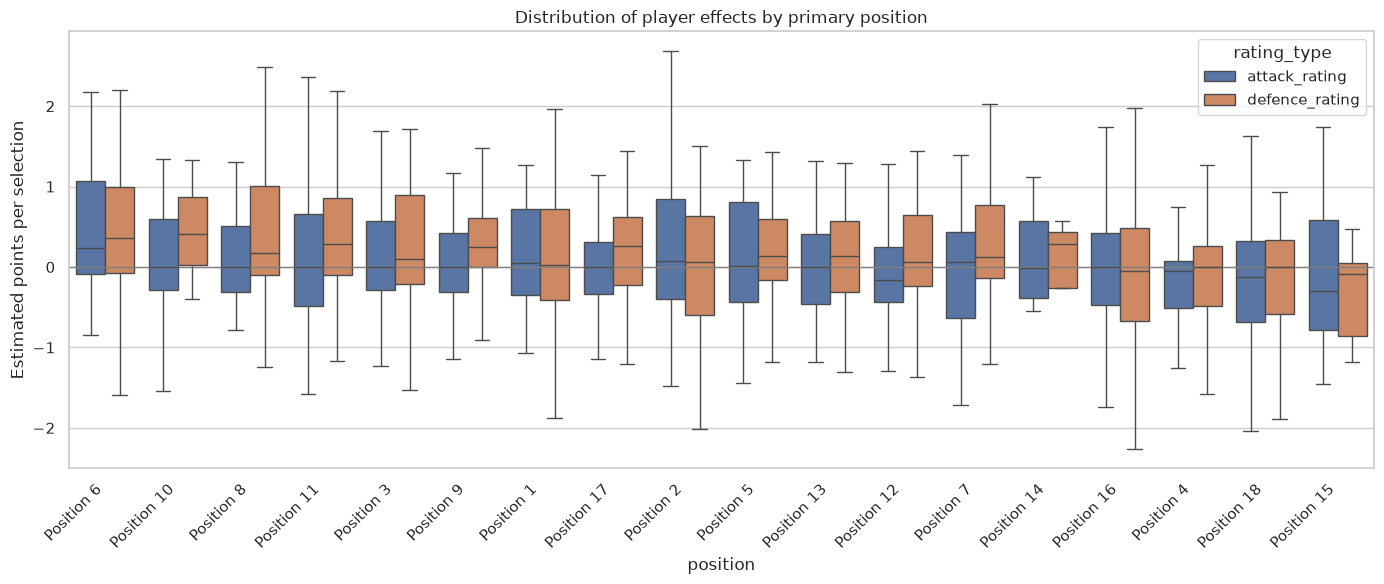

In [14]:
position_summary = ratings.groupby('position').agg(
    players=('player_id','size'), median_apps=('appearances','median'),
    mean_attack=('attack_rating','mean'), mean_defence=('defence_rating','mean'),
    mean_overall=('overall_rating','mean'),
    attack_spread=('attack_rating','std'), defence_spread=('defence_rating','std')
).sort_values('mean_overall', ascending=False)
display(position_summary)
plot_df = ratings.melt(id_vars=['player_name','position','appearances'],
                       value_vars=['attack_rating','defence_rating'], var_name='rating_type', value_name='points')
order_pos = position_summary.index.tolist()
plt.figure(figsize=(14,6))
sns.boxplot(data=plot_df, x='position', y='points', hue='rating_type', order=order_pos, showfliers=False)
plt.axhline(0,color='grey',lw=1); plt.xticks(rotation=45,ha='right')
plt.title('Distribution of player effects by primary position')
plt.ylabel('Estimated points per selection'); plt.tight_layout()

## 7. Who was missing, and what did it imply?
For each team-match, a player's absence is defined relative to the team's prior core squad: players with at least three appearances in that team's preceding eight fixtures. This is deliberately backward-looking. `missing_attack` and `missing_defence` sum the positive ratings of absent core players. Multiple absences therefore accumulate. We compare those quantities with residual scoring after removing broad team/opponent effects through the fitted model.

In [15]:
rating_lookup = ratings.set_index('player_id')[['attack_rating','defence_rating']]
selected_sets = players.groupby(['fixture_id','team_id']).player_id.agg(set).to_dict()
history = {}
absence_rows = []
for r in team_match.sort_values(ORDER_COL).itertuples():
    key = (r.fixture_id, r.team_id)
    selected = selected_sets.get(key,set())
    prior_sets = history.get(r.team_id, [])[-8:]
    counts = {}
    for s in prior_sets:
        for pid in s: counts[pid] = counts.get(pid,0)+1
    core = {pid for pid,n in counts.items() if n >= 3}
    missing = core - selected
    known_missing = [pid for pid in missing if pid in rating_lookup.index]
    missing_attack = rating_lookup.loc[known_missing,'attack_rating'].clip(lower=0).sum() if known_missing else 0
    missing_defence = rating_lookup.loc[known_missing,'defence_rating'].clip(lower=0).sum() if known_missing else 0
    absence_rows.append({'fixture_id':r.fixture_id,'team_id':r.team_id,'n_core_missing':len(missing),
                         'missing_attack':missing_attack,'missing_defence':missing_defence,
                         'missing_player_ids':known_missing})
    history.setdefault(r.team_id,[]).append(selected)
absence = pd.DataFrame(absence_rows)
absence = team_match.merge(absence,on=['fixture_id','team_id'])
absence['attack_shortfall'] = absence.groupby('team_id').points_for.transform('mean') - absence.points_for
absence['defence_shortfall'] = absence.points_against - absence.groupby('team_id').points_against.transform('mean')
display(absence[['n_core_missing','missing_attack','missing_defence','attack_shortfall','defence_shortfall']].corr())

,n_core_missing,missing_attack,missing_defence,attack_shortfall,defence_shortfall
n_core_missing,1.000,0.458,0.560,0.105,0.159
missing_attack,0.458,1.000,0.688,0.202,0.121
missing_defence,0.560,0.688,1.000,0.134,0.197
attack_shortfall,0.105,0.202,0.134,1.000,0.417
defence_shortfall,0.159,0.121,0.197,0.417,1.000


,matches,avg_points,avg_conceded,avg_margin
absent_band,,,,
0,57,19.421,22.912,-3.491
1,15,27.867,13.867,14.000
2,59,21.119,17.475,3.644
3-4,430,23.758,17.107,6.651
5+,1931,20.447,22.045,-1.598


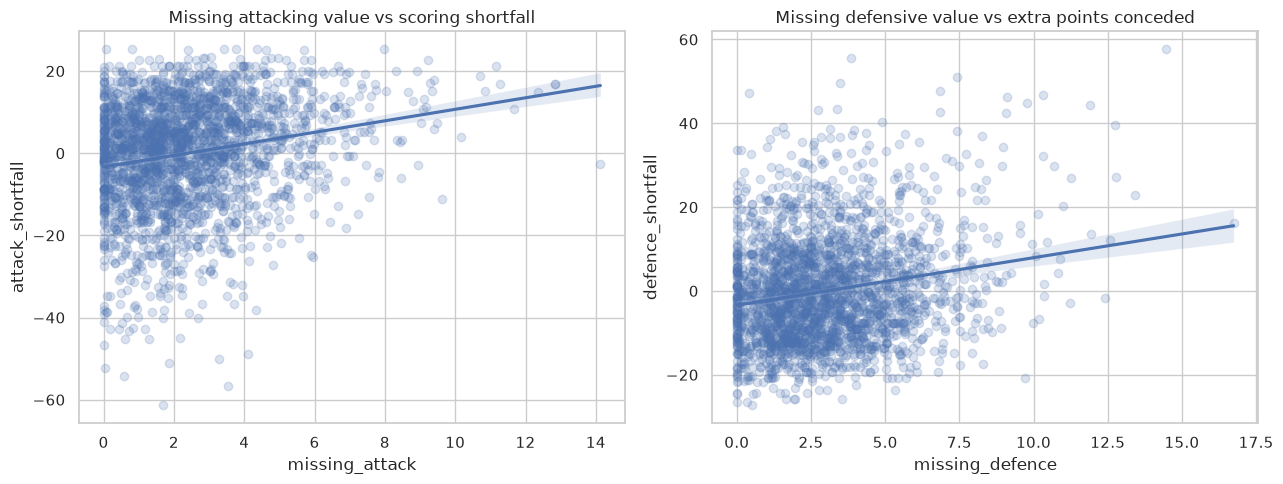

In [16]:
fig, ax = plt.subplots(1,2,figsize=(13,5))
sns.regplot(data=absence, x='missing_attack', y='attack_shortfall', scatter_kws={'alpha':.2}, ax=ax[0])
ax[0].set_title('Missing attacking value vs scoring shortfall')
sns.regplot(data=absence, x='missing_defence', y='defence_shortfall', scatter_kws={'alpha':.2}, ax=ax[1])
ax[1].set_title('Missing defensive value vs extra points conceded')
plt.tight_layout()
absence_bands = (absence.assign(absent_band=pd.cut(absence.n_core_missing,[-1,0,1,2,4,99],labels=['0','1','2','3-4','5+']))
                 .groupby('absent_band',observed=True).agg(matches=('fixture_id','size'),
                 avg_points=('points_for','mean'),avg_conceded=('points_against','mean'),avg_margin=('margin','mean')))
display(absence_bands)

## 8. Select a team and fixture to explain one or more absences

In [17]:
TEAM = absence.team_id.value_counts().index[0]  # change this
team_cases = absence[(absence.team_id==TEAM) & (absence.n_core_missing>0)].copy()
team_cases['estimated_margin_cost'] = team_cases.missing_attack + team_cases.missing_defence
display(team_cases.sort_values('estimated_margin_cost',ascending=False)[
    ['fixture_id','team_id','opposition_id','points_for','points_against','n_core_missing',
     'missing_attack','missing_defence','estimated_margin_cost']].head(15))

def explain_absences(fixture_id, team):
    row = absence[(absence.fixture_id==fixture_id)&(absence.team_id==team)].iloc[0]
    ids = row.missing_player_ids
    out = ratings[ratings.player_id.isin(ids)][['player_name','position','appearances','attack_rating','defence_rating','overall_rating']]
    return out.sort_values('overall_rating',ascending=False)

if len(team_cases):
    EXAMPLE_FIXTURE = team_cases.sort_values('estimated_margin_cost',ascending=False).fixture_id.iloc[0]
    print(f'Example: {TEAM}, fixture {EXAMPLE_FIXTURE}')
    display(explain_absences(EXAMPLE_FIXTURE, TEAM))

,fixture_id,team_id,opposition_id,points_for,points_against,n_core_missing,missing_attack,missing_defence,estimated_margin_cost
1143,10576,Wigan Warriors,Hull Kingston Rovers,28,38,16,14.129,13.429,27.558
2325,11168,Wigan Warriors,Hull Kingston Rovers,4,62,15,11.172,10.320,21.491
493,10247,Wigan Warriors,St Helens,0,42,15,7.961,11.249,19.209
681,10344,Wigan Warriors,Wakefield Trinity,6,14,8,6.899,10.368,17.268
971,10489,Wigan Warriors,Huddersfield Giants,22,32,11,7.144,7.651,14.795
693,10350,Wigan Warriors,Warrington Wolves,14,40,8,5.903,8.012,13.916
1291,10650,Wigan Warriors,Hull FC,10,14,7,7.756,6.137,13.893
1289,10649,Wigan Warriors,Wakefield Trinity,22,6,6,8.343,4.889,13.232
2411,11211,Wigan Warriors,Warrington Wolves,30,18,7,7.826,5.049,12.875
1549,10780,Wigan Warriors,London Broncos,60,22,9,3.956,8.440,12.395


Example: Wigan Warriors, fixture 10576


,player_name,position,appearances,attack_rating,defence_rating,overall_rating
164,Bevan French,Position 6,132,2.996,2.201,5.197
175,Kaide Ellis,Position 13,121,2.773,0.971,3.744
162,Jai Field,Position 1,118,2.780,0.710,3.490
136,Brad Singleton,Position 8,139,0.105,2.399,2.504
172,Liam Farrell,Position 12,172,1.404,0.430,1.834
177,Brad O'Neill,Position 9,106,1.056,0.526,1.582
204,Sam Powell,Position 9,166,0.126,1.257,1.383
178,Willie Isa,Position 11,107,0.817,0.438,1.255
404,Morgan Smithies,Position 13,105,0.354,0.568,0.922
168,Harry Smith,Position 7,162,0.438,0.366,0.803


## 9. Essential caveats and next improvements

1. **Validate team-name alignment** whenever new Patreon files arrive. This notebook assumes the player and results feeds use the same club names per fixture.
2. **Validate position codes** before naming them. Codes 19 and 9999 appear anomalous.
3. **Selection is not random.** Injuries, coaching choices and match context confound player effects. Treat ratings as predictive associations.
4. **Player combinations are collinear.** Ridge stabilises estimates, but regular pairings can still be difficult to separate.
5. **Walk-forward production model:** refit ratings at every round using only prior fixtures. This notebook holds out the latest 20%; it does not yet produce a rating snapshot for every historic round.
6. **Next model:** add season effects, rest days, and pre-match team strength; then tune `RIDGE_ALPHA` on rolling validation rather than choosing it manually. Home/away is now available and already included as a fixed effect.
7. **Uncertainty:** bootstrap fixtures by chronological blocks and display rating intervals. Do not act on small differences whose intervals overlap zero.

## Rolling-window backtest

This final check asks a simpler question: does the gated blend keep adding value across multiple time periods, rather than only on one train/test split?

The idea is to move through the fixture timeline in rolling windows, compute mean absolute error for the baseline, main blend, interaction blend, and gated blend, and then compare them side by side. If the gated model consistently improves on the single-model versions, the benefit is more credible and less likely to be a quirk of one particular split.


,window_label,rows,baseline_mae,main_mae,interaction_mae,gated_mae,gated_gain_vs_main,gated_gain_vs_interaction,high_disruption_share
0,2019-01-31 to 2020-03-05,415,9.842,8.731,8.772,8.743,-0.012,0.029,0.313
1,2019-06-14 to 2021-05-02,415,9.825,7.903,8.033,7.940,-0.037,0.093,0.306
2,2020-03-05 to 2021-09-23,415,9.667,7.868,7.941,7.948,-0.080,-0.007,0.292
3,2021-05-02 to 2022-07-02,415,9.715,8.185,8.201,8.271,-0.086,-0.071,0.304
4,2021-09-23 to 2023-03-30,415,9.751,8.316,8.342,8.391,-0.075,-0.049,0.313
5,2022-07-02 to 2023-09-01,415,9.667,8.319,8.315,8.352,-0.034,-0.037,0.330
6,2023-03-30 to 2024-06-01,415,9.991,8.290,8.320,8.325,-0.035,-0.005,0.308
7,2023-09-01 to 2025-02-23,415,10.413,8.264,8.364,8.375,-0.111,-0.010,0.308
8,2024-06-01 to 2025-07-25,415,10.118,8.028,8.092,8.054,-0.025,0.039,0.306
9,2025-02-23 to 2026-04-18,415,10.084,8.758,8.804,8.711,0.047,0.093,0.308


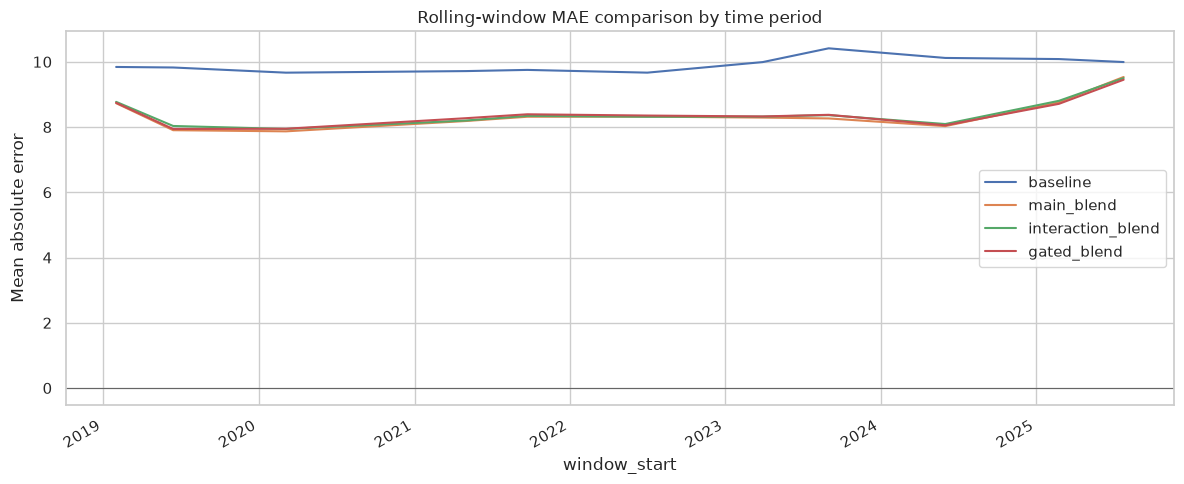

In [18]:
# Rolling-window backtest: check whether the gated advantage persists across time periods.
# Use a simple chronological window scan on the full fixture set, not just the final train/test split.

backtest_source = variant_frame.sort_values(['fixture_date', 'source_fixture_id']).copy().reset_index(drop=True)

window_size = max(30, len(backtest_source) // 6)
step = max(15, window_size // 2)
backtest_rows = []

for start in range(0, len(backtest_source) - window_size + 1, step):
    end = start + window_size
    window = backtest_source.iloc[start:end].copy()

    q80_top3 = window['missing_core_top3_sum'].quantile(0.80)
    q80_halves = window['missing_halves_6_7_sum'].quantile(0.80)
    window['high_disruption_window'] = (
        (window['missing_core_top3_sum'] >= q80_top3)
        | (window['missing_halves_6_7_sum'] >= q80_halves)
    )

    window['abs_error_baseline'] = (window['points_for'] - window['baseline_expected_points']).abs()
    window['abs_error_main'] = (window['points_for'] - window['blended_expected_points']).abs()
    window['abs_error_interaction'] = (window['points_for'] - window['variant_blended_expected_points']).abs()
    window['gated_expected_points'] = np.where(
        window['high_disruption_window'],
        window['blended_expected_points'],
        window['variant_blended_expected_points'],
    )
    window['abs_error_gated'] = (window['points_for'] - window['gated_expected_points']).abs()

    backtest_rows.append({
        'window_start': window['fixture_date'].min(),
        'window_end': window['fixture_date'].max(),
        'rows': int(len(window)),
        'baseline_mae': float(window['abs_error_baseline'].mean()),
        'main_mae': float(window['abs_error_main'].mean()),
        'interaction_mae': float(window['abs_error_interaction'].mean()),
        'gated_mae': float(window['abs_error_gated'].mean()),
        'gated_gain_vs_main': float(window['abs_error_main'].mean() - window['abs_error_gated'].mean()),
        'gated_gain_vs_interaction': float(window['abs_error_interaction'].mean() - window['abs_error_gated'].mean()),
        'high_disruption_share': float(window['high_disruption_window'].mean()),
    })

rolling_backtest = pd.DataFrame(backtest_rows).sort_values('window_start').reset_index(drop=True)
rolling_backtest['window_label'] = rolling_backtest['window_start'].dt.strftime('%Y-%m-%d') + ' to ' + rolling_backtest['window_end'].dt.strftime('%Y-%m-%d')

display(rolling_backtest[['window_label', 'rows', 'baseline_mae', 'main_mae', 'interaction_mae', 'gated_mae', 'gated_gain_vs_main', 'gated_gain_vs_interaction', 'high_disruption_share']])

plot_df = rolling_backtest.set_index('window_start')[['baseline_mae', 'main_mae', 'interaction_mae', 'gated_mae']].copy()
plot_df.columns = ['baseline', 'main_blend', 'interaction_blend', 'gated_blend']
plot_df.plot(figsize=(12, 5), title='Rolling-window MAE comparison by time period')
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
plt.ylabel('Mean absolute error')
plt.tight_layout()


## Walk-forward validation: the real production test

This backtest is intentionally different from a single hold-out split. We train on all fixtures before each evaluation date and score the next date only, so the results reflect the information that would actually have been available in production.

The key question is simple: does the player-adjusted expected points improve on the baseline across chronological folds?
